# Initial Exploratory Data Analysis (EDA)
The purpose of this EDA is to understand the characteristics of the dataset, detect missing values and outliers, and explore the relationship between features and the target variable (`loan_status`). This helps us identify potential predictors for alternative credit scoring in Cambodia's informal market.

In [16]:
# Import libraries
import pandas as pd

In [17]:
# Import the raw dataset
df = pd.read_csv("../data/raw/credit_risk_dataset.csv")

### Dataset Shape and Features

In [18]:
# show number of rows and colums
print(df.shape)
# show all colums
print(df.columns)
# show features info
print(df.info())
# preview 
df.head()

(32581, 12)
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Summary Statistics for Numerical Features

In [5]:
# Descibe the numerical dataset
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Duplicated values

In [6]:
# Find duplicate value
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 165


### Missing values

In [7]:
print(df.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


### Outlier detection of numerical features

In [8]:
# Check outlier of numerical columns
numerical_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    lower_outliers = df[df[col] < lower]
    upper_outliers = df[df[col] > upper]

    total_outliers = len(lower_outliers) + len(upper_outliers)

    print(f"{col}: {total_outliers} total outliers "
          f"({total_outliers/len(df)*100:.2f}%)")
    print(f"  Lower bound = {lower}, lower bound outliers = {len(lower_outliers)}")
    print(f"  Upper bound = {upper}, upper bound outliers = {len(upper_outliers)}\n")

person_age: 1494 total outliers (4.59%)
  Lower bound = 12.5, lower bound outliers = 0
  Upper bound = 40.5, upper bound outliers = 1494

person_income: 1484 total outliers (4.55%)
  Lower bound = -22550.0, lower bound outliers = 0
  Upper bound = 140250.0, upper bound outliers = 1484

person_emp_length: 853 total outliers (2.62%)
  Lower bound = -5.5, lower bound outliers = 0
  Upper bound = 14.5, upper bound outliers = 853

loan_amnt: 1689 total outliers (5.18%)
  Lower bound = -5800.0, lower bound outliers = 0
  Upper bound = 23000.0, upper bound outliers = 1689

loan_int_rate: 6 total outliers (0.02%)
  Lower bound = -0.45500000000000007, lower bound outliers = 0
  Upper bound = 21.825000000000003, upper bound outliers = 6

loan_percent_income: 651 total outliers (2.00%)
  Lower bound = -0.12000000000000002, lower bound outliers = 0
  Upper bound = 0.44000000000000006, upper bound outliers = 651

cb_person_cred_hist_length: 1142 total outliers (3.51%)
  Lower bound = -4.5, lower bo

### Plot graphs

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

### Boxplot of numerical features

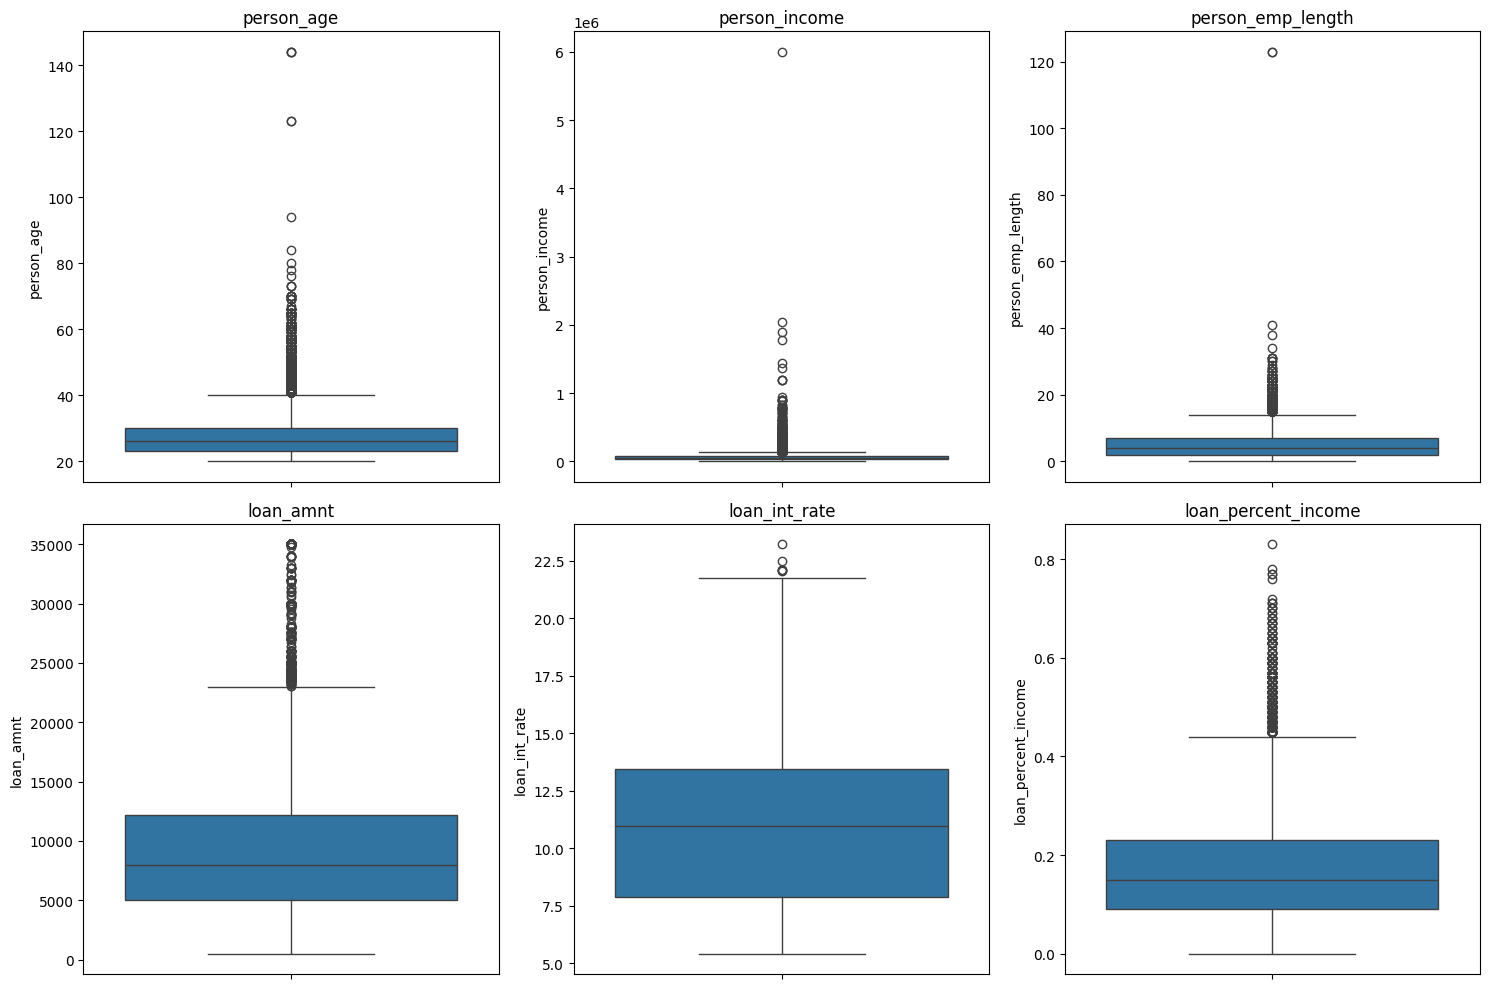

In [11]:
# Boxplot of numerical features
num_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income'
]

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.savefig("../outputs/figures/inital_eda/boxplot_numerical.png")
plt.show()

### Compare person age and person employee lenght

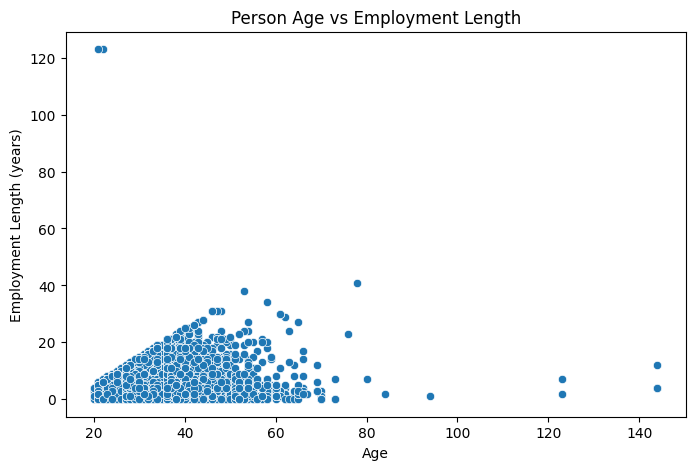

In [12]:
# Compare person age and person employee lenght
plt.figure(figsize=(8,5))
sns.scatterplot(x='person_age', y='person_emp_length', data=df)

plt.title("Person Age vs Employment Length")
plt.xlabel("Age")
plt.ylabel("Employment Length (years)")
plt.savefig("../outputs/figures/inital_eda/compare_age_emp-length.png")
plt.show()

### Plot Correlation matrix

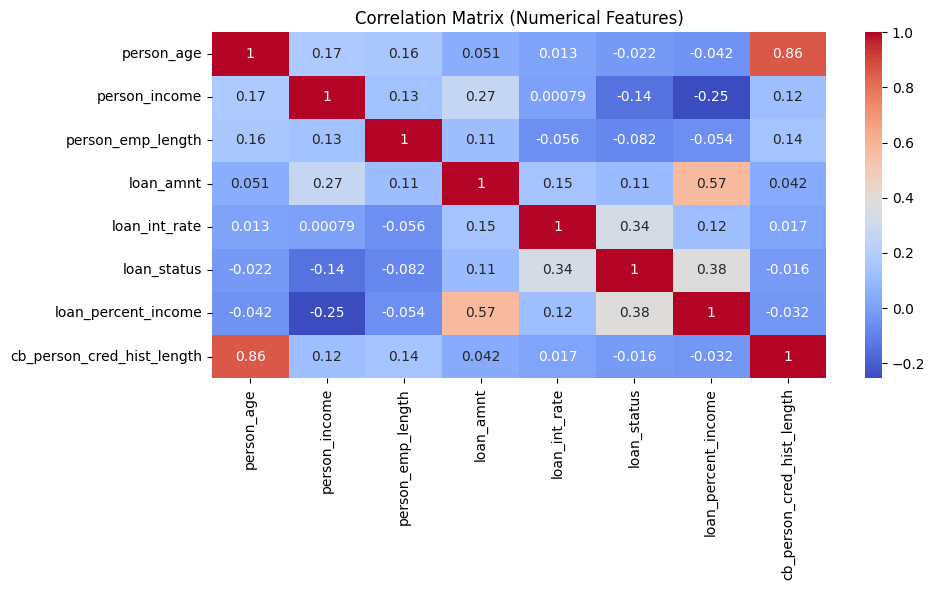

In [25]:
# Select numerical features
num_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = num_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.savefig("../outputs/figures/inital_eda/correlation_matrix.png")
plt.show()

### Categorical Feature Distribution

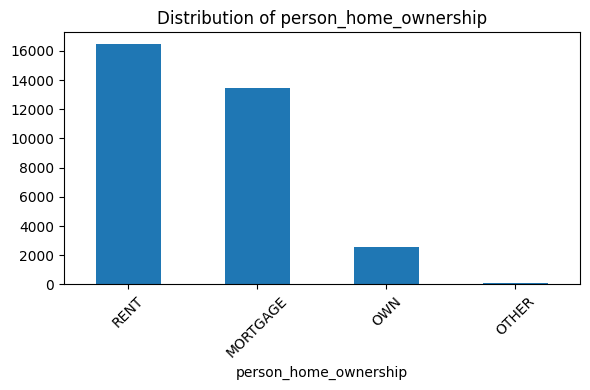

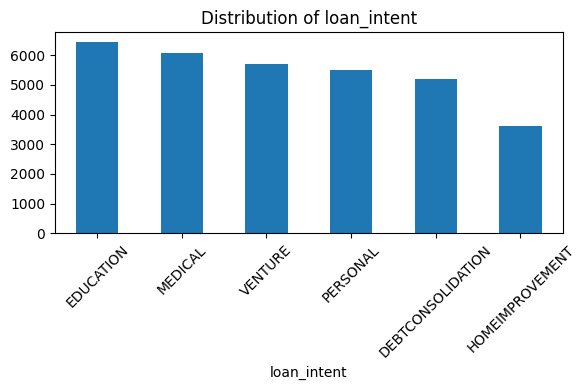

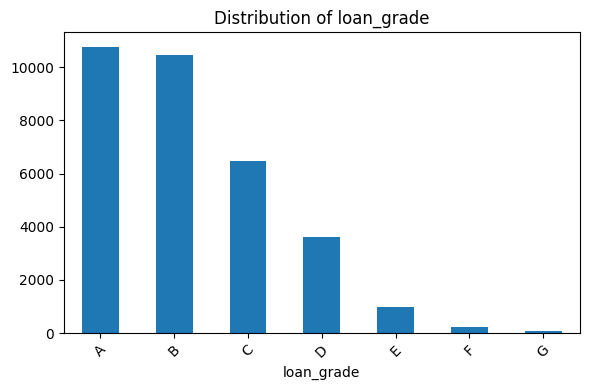

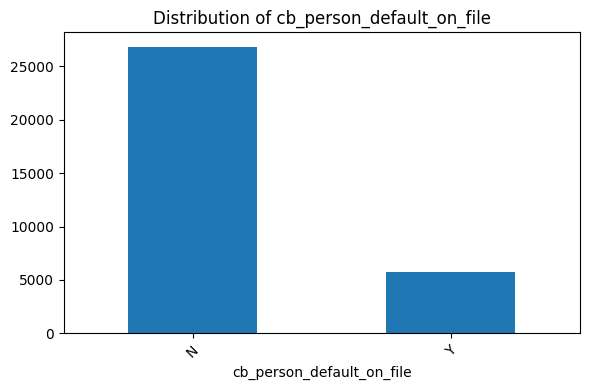

In [21]:
categorical_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/inital_eda/categorical_feature_distribution_{col}.png")
    plt.show()

### Relationship Between Features and Loan Status

In [22]:
df.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False)

person_home_ownership
RENT        0.315700
OTHER       0.308411
MORTGAGE    0.125707
OWN         0.074690
Name: loan_status, dtype: float64

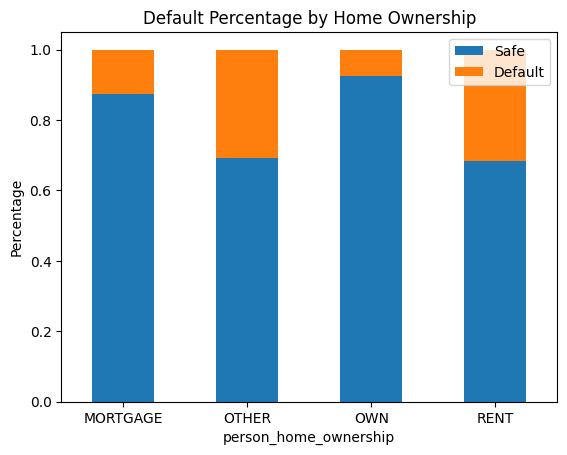

In [23]:
pd.crosstab(
    df['person_home_ownership'],
    df['loan_status'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Default Percentage by Home Ownership')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(['Safe', 'Default'])
plt.savefig("../outputs/figures/inital_eda/default_percentage_by_home_ownership.png")
plt.show()

In [24]:
df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)

loan_intent
DEBTCONSOLIDATION    0.285879
MEDICAL              0.267007
HOMEIMPROVEMENT      0.261026
PERSONAL             0.198877
EDUCATION            0.172168
VENTURE              0.148103
Name: loan_status, dtype: float64

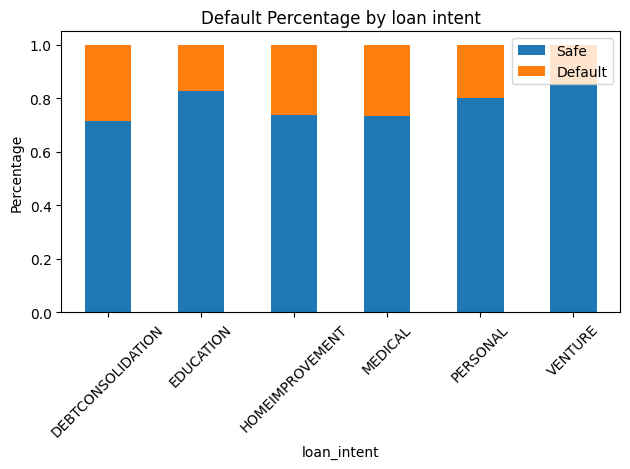

In [26]:
pd.crosstab(
    df['loan_intent'],
    df['loan_status'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Default Percentage by loan intent')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(['Safe', 'Default'])
plt.tight_layout()
plt.savefig("../outputs/figures/inital_eda/default_percentage_by_loan_intent.png")
plt.show()

In [27]:
df.groupby('cb_person_default_on_file')['loan_status'].mean().sort_values(ascending=False)

cb_person_default_on_file
Y    0.378068
N    0.183932
Name: loan_status, dtype: float64

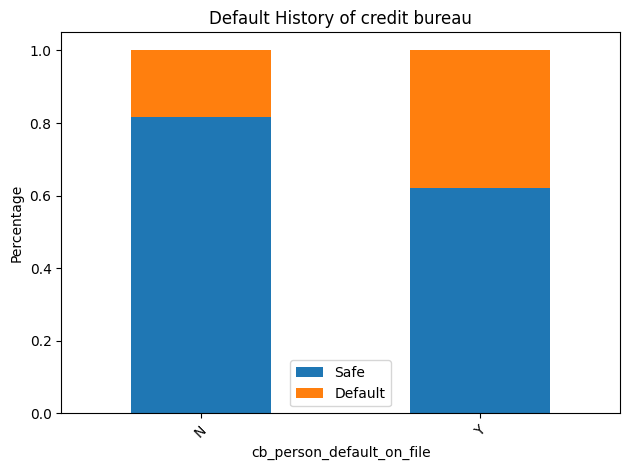

In [28]:
pd.crosstab(
    df['cb_person_default_on_file'],
    df['loan_status'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title('Default History of credit bureau')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(['Safe', 'Default'])
plt.tight_layout()
plt.savefig("../outputs/figures/inital_eda/default_history_of_credit_bureau.png")
plt.show()